# Multicoordinate Wave Project

Generate one wave project containing several coordinate systems and inspect the coordinate-specific artifacts.

Navigation: [Index](../index.ipynb) | Previous: [GeneralRFM and Fisheye Coordinates](../4-curvilinear/generalrfm_and_fisheye.ipynb) | Next: [BHaH Project Anatomy](../5-infrastructures/bhah_project_anatomy.ipynb)


## Learning Goals

- Generate one project that contains several coordinate systems.
- Find which directories belong to which coordinates.
- Run the executable and inspect one diagnostic output per coordinate choice.

## Words for This Notebook

- **Coordinate option:** one grid choice available inside the same generated project.
- **Runtime parameter:** a value chosen when the program runs, without regenerating code.
- **Diagnostic file:** a text file written by the run so results can be compared.
- **Executable:** the compiled program shared by the coordinate options.

Use the code cells actively: first predict what should happen, then run the cell, then explain the output in plain language. This predict-run-explain pattern keeps the physics idea connected to the programming details.


## Generate and Run the Multicoordinate Project
The project contains coordinate-specific directories and diagnostics for Cartesian, Spherical, SinhCartesian, and SinhSpherical grids.

## Import Multicoordinate Project Execution Helpers

These standard-library tools run commands, manage temporary project directories, and clean command output.

If you are new to Python, do not study this helper cell line by line on a first pass. Its job is practical: run terminal commands, shorten long command output, and stop with a clear message if a required tool is missing. Focus first on the cells that generate, inspect, build, run, and interpret the physics project.


In [1]:
from pathlib import Path
import re, shutil, subprocess, sys, tempfile


def clean_command_output(text):
    cleaned = re.sub(r"\x1b\[[0-?]*[ -/]*[@-~]", "", text or "")
    return cleaned.replace(str(WORKSPACE), "<workspace>")


def run_command(args, cwd, timeout):
    try:
        result = subprocess.run(
            args,
            cwd=cwd,
            text=True,
            stdout=subprocess.PIPE,
            stderr=subprocess.STDOUT,
            check=True,
            timeout=timeout,
        )
    except FileNotFoundError as exc:
        raise RuntimeError(f"Required command is missing: {args[0]}") from exc
    except subprocess.CalledProcessError as exc:
        print(clean_command_output(exc.stdout))
        raise RuntimeError(f"Command failed: {' '.join(map(str, args))}") from exc
    return clean_command_output(result.stdout)


def require_toolchain():
    if shutil.which("make") is None:
        raise RuntimeError(
            "This notebook requires make to build the generated project."
        )
    if not any(shutil.which(name) for name in ["cc", "gcc", "clang"]):
        raise RuntimeError(
            "This notebook requires a C compiler such as cc, gcc, or clang."
        )


## Create a Multicoordinate Workspace

The workspace keeps generated files separate from the tutorial source tree.


In [2]:
PROJECT_NAME = "wave_equation_multicoordinates"
workspace_manager = tempfile.TemporaryDirectory(
    prefix="nrpy_tutorial_multi_", dir=Path.cwd()
)
WORKSPACE = Path(workspace_manager.name)
PROJECT_DIR = WORKSPACE / "project" / PROJECT_NAME


## Generate the Multicoordinate Project

This command invokes the same module a learner can run from a terminal and then verifies that the project directory exists.


In [3]:
command = [sys.executable, "-m", "nrpy.examples.wave_equation_multicoordinates"]
print("generator command: python -m nrpy.examples.wave_equation_multicoordinates")
output = run_command(command, WORKSPACE, timeout=300)
for line in output.splitlines():
    if line.strip():
        print(line.rstrip())
if not PROJECT_DIR.is_dir():
    raise FileNotFoundError(PROJECT_DIR)


generator command: python -m nrpy.examples.wave_equation_multicoordinates


In 0.008s, worker completed task 'register_CFunction_initial_data'
In 0.005s, worker completed task 'register_CFunction_diagnostics_nearest_1d_y_and_z_axes'
In 0.006s, worker completed task 'register_CFunction_diagnostics_nearest_grid_center'
In 0.007s, worker completed task '_register_CFunction_diagnostics'
In 0.006s, worker completed task 'register_CFunction_diagnostics_nearest_grid_center'
In 0.006s, worker completed task 'register_CFunction_diagnostics_nearest_2d_xy_and_yz_planes'
In 0.005s, worker completed task 'register_CFunction_diagnostics_nearest_grid_center'
In 0.006s, worker completed task 'register_CFunction_diagnostics_nearest_grid_center'
In 0.007s, worker completed task 'register_CFunction_diagnostics_nearest_2d_xy_and_yz_planes'
In 0.007s, worker completed task 'register_CFunction_diagnostics_nearest_1d_y_and_z_axes'
In 0.007s, worker completed task 'register_CFunction_diagnostics_nearest_1d_y_and_z_axes'
In 0.006s, worker completed task 'register_CFunction_diagnostics

## Step 4: Shorten runtime parameters

Only runtime values are changed so the notebook run finishes quickly.

In [4]:
parfile = PROJECT_DIR / "wave_equation_multicoordinates.par"
par_text = parfile.read_text(encoding="utf-8")
par_text = par_text.replace("t_final = 8.0", "t_final = 0.2")
par_text = par_text.replace(
    "diagnostics_output_every = 0.2", "diagnostics_output_every = 0.1"
)
par_text = par_text.replace(
    "output_progress_every = 1", "output_progress_every = 1000000"
)
parfile.write_text(par_text, encoding="utf-8")
print(f"--- runtime {parfile.name} ---")
print(parfile.read_text(encoding="utf-8", errors="replace"))


--- runtime wave_equation_multicoordinates.par ---
#### wave_equation_multicoordinates BH@H parameter file. NOTE: only commondata CodeParameters appear here ###
###########################
###########################
### Module: nrpy.equations.wave_equation.WaveEquationCurvilinear_RHSs
wavespeed = 1.0                 # (REAL)
###########################
###########################
### Module: nrpy.equations.wave_equation.WaveEquation_Solutions_InitialData
sigma = 3.0                     # (REAL)
###########################
###########################
### Module: nrpy.infrastructures.BHaH.CurviBoundaryConditions.register_all
outer_bc_type = "radiation"     # (char[50])
###########################
###########################
### Module: nrpy.infrastructures.BHaH.MoLtimestepping.register_all
CFL_FACTOR = 0.5                # (REAL)
t_final = 0.2                   # (REAL)
###########################
###########################
### Module: nrpy.infrastructures.BHaH.checkpointing
checkpoint

## Inspect Coordinate-Specific Directories

The output shows the Runge-Kutta or Method of Lines objects used by generated code.


In [5]:
coordinate_dirs = [
    path.name
    for path in PROJECT_DIR.iterdir()
    if path.is_dir() and path.name not in {"MoL", "diagnostics", "intrinsics"}
]
print("coordinate directories:")
for name in sorted(coordinate_dirs):
    print(name)
missing = {"Cartesian", "SinhCartesian", "SinhSpherical", "Spherical"}.difference(
    set(coordinate_dirs)
)
if missing:
    raise RuntimeError(f"Missing coordinate directories: {sorted(missing)}")


coordinate directories:
Cartesian
SinhCartesian
SinhSpherical
Spherical


## Step 6: Inspect the generated inventory

The inventory identifies the generated files relevant to this lesson.

In [6]:
print("coordinate directories and core files:")
for name in sorted(coordinate_dirs):
    print(name + "/")
for relative_path in ["Makefile", "BHaH_function_prototypes.h", parfile.name]:
    print(relative_path)


coordinate directories and core files:
Cartesian/
SinhCartesian/
SinhSpherical/
Spherical/
Makefile
BHaH_function_prototypes.h
wave_equation_multicoordinates.par


## Step 7: Inspect the multicoordinate parameter file

The parameter file records the coordinate systems available to the generated executable.

In [7]:
print("\n--- wave_equation_multicoordinates.par ---")
print(parfile.read_text(encoding="utf-8", errors="replace"))



--- wave_equation_multicoordinates.par ---
#### wave_equation_multicoordinates BH@H parameter file. NOTE: only commondata CodeParameters appear here ###
###########################
###########################
### Module: nrpy.equations.wave_equation.WaveEquationCurvilinear_RHSs
wavespeed = 1.0                 # (REAL)
###########################
###########################
### Module: nrpy.equations.wave_equation.WaveEquation_Solutions_InitialData
sigma = 3.0                     # (REAL)
###########################
###########################
### Module: nrpy.infrastructures.BHaH.CurviBoundaryConditions.register_all
outer_bc_type = "radiation"     # (char[50])
###########################
###########################
### Module: nrpy.infrastructures.BHaH.MoLtimestepping.register_all
CFL_FACTOR = 0.5                # (REAL)
t_final = 0.2                   # (REAL)
###########################
###########################
### Module: nrpy.infrastructures.BHaH.checkpointing
checkpoint_every 

## Step 8: Build the executable

The build step compiles generated C after checking that external build tools are available.

In [8]:
require_toolchain()
build_output = run_command(["make", "-j2"], PROJECT_DIR, timeout=300)
print("build completed")
print("compiler output line count:", len(build_output.splitlines()))


build completed
compiler output line count: 82


## Step 9: Run the executable

The run produces diagnostic files that are inspected in the following cells.

In [9]:
run_output = run_command([f"./{PROJECT_NAME}", "2.0"], PROJECT_DIR, timeout=120)
print("run output:")
for line in run_output.splitlines()[:12]:
    if line.strip():
        print(line.rstrip())


run output:
It: 0 t=0.000 / 0.2 = 0.00% dt=1/483.7 | t/h=0.00 ETA 0h00m00s
WRITING CHECKPOINT: cd struct size = 168 time=0.000000e+00
FINISHED WRITING CHECKPOINT


## Read Multicoordinate Diagnostics

The diagnostic rows provide the numerical evidence used for interpretation.


In [10]:
diagnostics = sorted(PROJECT_DIR.glob("out0d-grid*.txt"))
if not diagnostics:
    raise FileNotFoundError("No diagnostic files were produced.")
for diagnostic in diagnostics:
    rows = [
        line
        for line in diagnostic.read_text(
            encoding="utf-8", errors="replace"
        ).splitlines()
        if line.strip() and not line.lstrip().startswith("#")
    ]
    if len(rows) < 2:
        raise RuntimeError(f"Expected at least two rows in {diagnostic.name}.")
    print(diagnostic.name, "rows:", len(rows), "last row:", rows[-1])


out0d-grid00-Cartesian-conv_factor-2.00.txt rows: 2 last row: 9.923527388139200e-02 1.001377001799009e-09 -1.219801401297098e-06 3.994691040667144e+00 3.994691036666953e+00
out0d-grid01-SinhCartesian-conv_factor-2.00.txt rows: 2 last row: 9.923527388139200e-02 4.561369981281592e-09 -4.705439066190487e-06 3.996709750973538e+00 3.996709732743066e+00
out0d-grid02-SinhSpherical-conv_factor-2.00.txt rows: 2 last row: 9.923527388139200e-02 7.379075278350336e-10 -8.528173033443453e-07 3.996718184800114e+00 3.996718181850905e+00
out0d-grid03-Spherical-conv_factor-2.00.txt rows: 2 last row: 9.923527388139200e-02 1.465432766608232e-10 -1.783132577084108e-07 3.996549878756188e+00 3.996549878170521e+00


## Plot Multicoordinate Diagnostics

The files now represent different coordinate choices. Plotting them together makes the comparison about numerical behavior, not just file names.

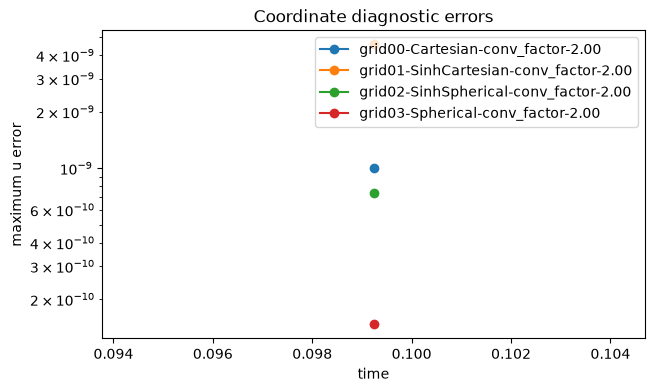

In [11]:
import matplotlib.pyplot as plt


plt.figure(figsize=(7, 4))
for diagnostic in diagnostics:
    rows = [
        [float(value) for value in line.split()]
        for line in diagnostic.read_text(
            encoding="utf-8", errors="replace"
        ).splitlines()
        if line.strip() and not line.lstrip().startswith("#")
    ]
    positive_rows = [row for row in rows if row[1] > 0.0]
    times = [row[0] for row in positive_rows]
    errors = [row[1] for row in positive_rows]
    label = diagnostic.stem.replace("out0d-", "")
    plt.plot(times, errors, marker="o", label=label)
plt.yscale("log")
plt.xlabel("time")
plt.ylabel("maximum u error")
plt.title("Coordinate diagnostic errors")
plt.legend()
plt.show()

The coordinate directories and runtime parameter file show one generated project carrying several coordinate systems. The diagnostics demonstrate that each grid writes its own output using the same executable.


## Learning Check

Before running, predict which coordinate names should appear as generated directories. After inspection, list one thing that is shared and one thing that differs between coordinates.


## Continue to Project Anatomy
- [GeneralRFM and Fisheye Coordinates](../4-curvilinear/generalrfm_and_fisheye.ipynb)
- [Curvilinear Boundary Conditions](../4-curvilinear/curvilinear_boundary_conditions.ipynb)
- [BHaH Project Anatomy](../5-infrastructures/bhah_project_anatomy.ipynb)
